# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

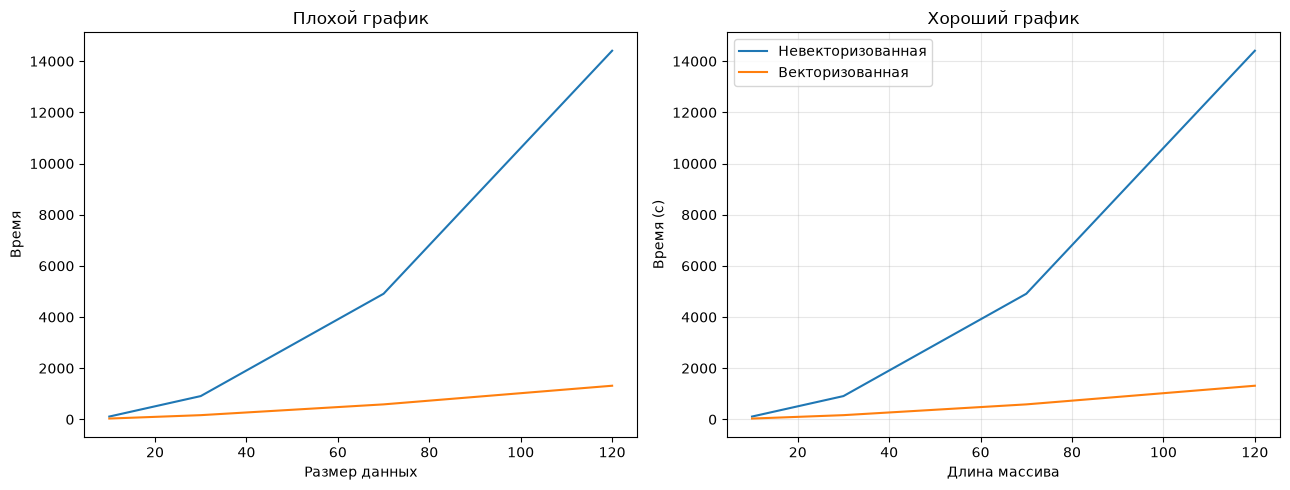

In [1]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

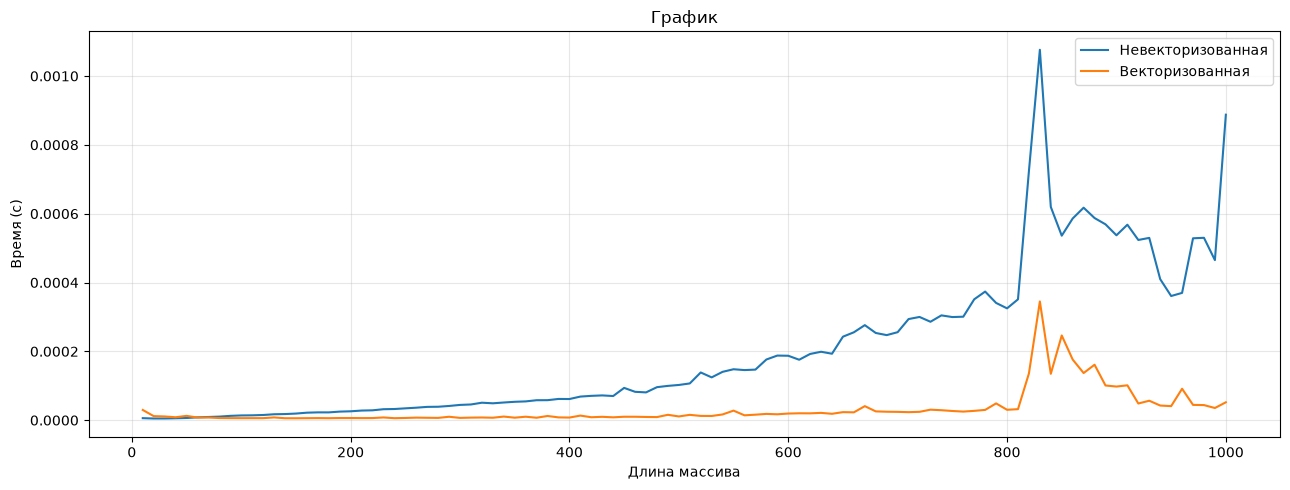

In [1]:
import time
import numpy
import matplotlib.pyplot as mat

def function1(x) :
    ans = 1
    for i in range(min(len(x), len(x[0]))):
        if (x[i][i] != 0):
            ans *= x[i][i]
    return ans

def function2(x):
    a = numpy.diag(x)
    ans = a[a != 0].prod()
    return ans

size = []
time1 = []
time2 = [];

for si in range(10, 1001, 10):
    size.append(si)
    x = (numpy.random.default_rng()).integers(-100, 101, size=(si, si))
    y = x.tolist()
    t = time.perf_counter();
    function1(y);
    time1.append(time.perf_counter() - t);
    t = time.perf_counter();
    function2(x);
    time2.append(time.perf_counter() - t);

figure, (axis_good) = mat.subplots(1, 1, figsize=(13, 5))

axis_good.plot(size, time1, label="Невекторизованная")
axis_good.plot(size, time2, label="Векторизованная")
axis_good.set_title("График")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
mat.show()


 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


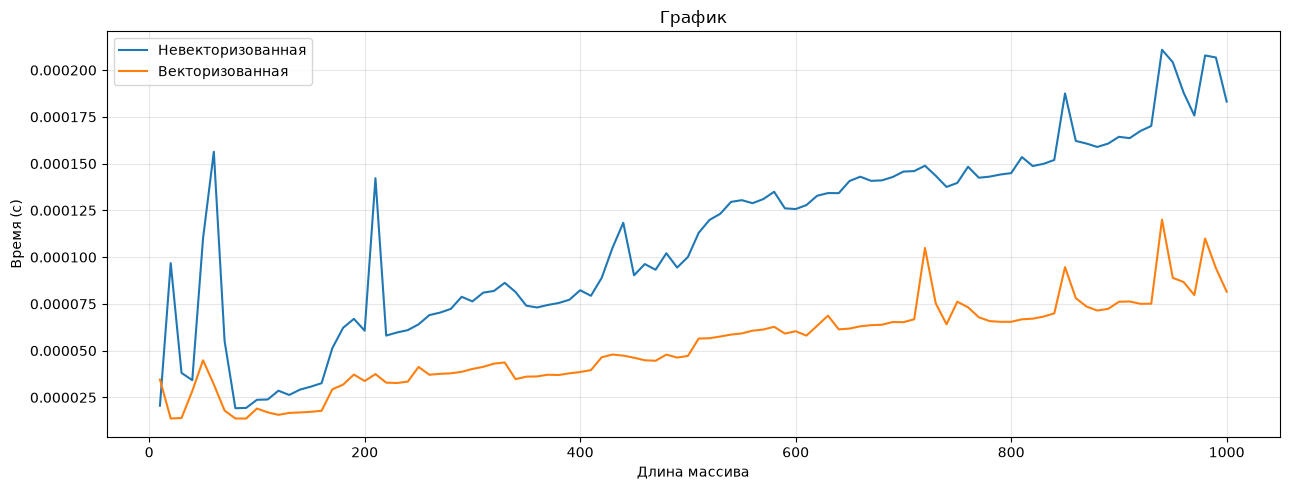

In [4]:
import time
import numpy
import matplotlib.pyplot as mat

def function1(x, y) :
    x.sort();
    y.sort();
    f = 1;
    if (len(x) != len(y)):
        f = 0
    for i in range(len(x)):
        if (x[i] != y[i]):
            f = 0
    if f:
        return True;
    else:
        return False;
    

def function2(x, y):
    return numpy.array_equal(x, y);

size = []
time1 = []
time2 = [];

for si in range(10, 1001, 10):
    size.append(si)
    x1 = (numpy.random.default_rng()).integers(-100, 101, size=(si));
    y1 = (numpy.random.default_rng()).integers(-100, 101, size=(si));
    x2 = x1.tolist()
    y2 = y1.tolist()
    t = time.perf_counter();
    function1(x1, y1);
    time1.append(time.perf_counter() - t);
    t = time.perf_counter();
    function2(x2, y2);
    time2.append(time.perf_counter() - t);

figure, (axis_good) = mat.subplots(1, 1, figsize=(13, 5))

axis_good.plot(size, time1, label="Невекторизованная")
axis_good.plot(size, time2, label="Векторизованная")
axis_good.set_title("График")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
mat.show()


* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

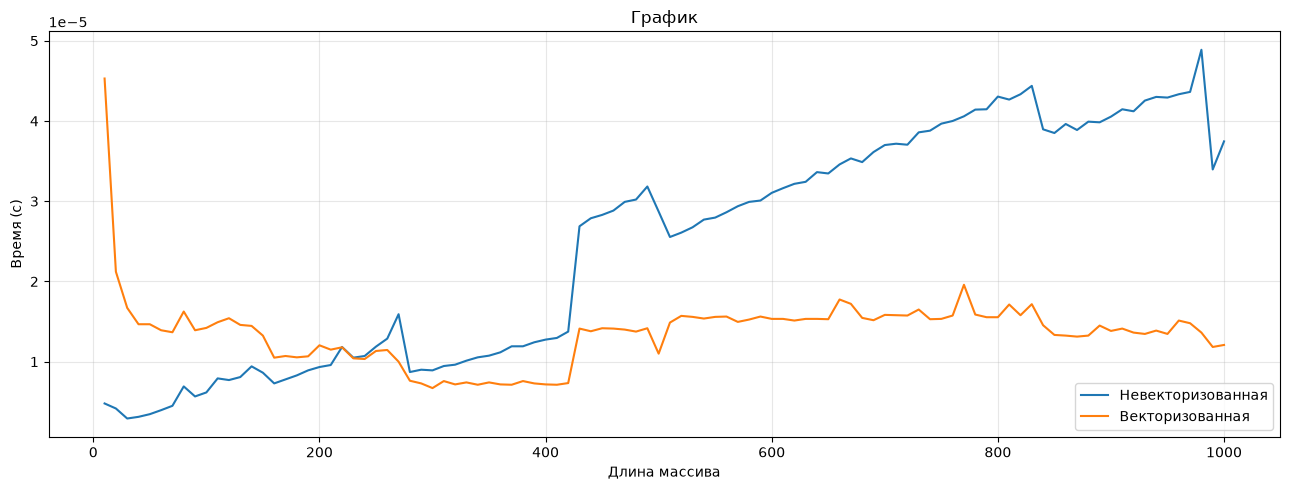

In [10]:
import time
import numpy
import matplotlib.pyplot as mat

def function1(x) :
    ans = -1001;
    for i in range(len(x) - 1):
        if (x[i] == 0):
            ans = max(ans, x[i + 1])
    return ans

def function2(x):
    a = x[1:][x[:-1] == 0]
    a = numpy.append(a, -1001);
    return a.max();

size = []
time1 = []
time2 = [];

for si in range(10, 1001, 10):
    size.append(si)
    x = (numpy.random.default_rng()).integers(-100, 101, size=(si))
    y = x.tolist()
    t = time.perf_counter();
    function1(y);
    time1.append(time.perf_counter() - t);
    t = time.perf_counter();
    function2(x);
    time2.append(time.perf_counter() - t);

figure, (axis_good) = mat.subplots(1, 1, figsize=(13, 5))

axis_good.plot(size, time1, label="Невекторизованная")
axis_good.plot(size, time2, label="Векторизованная")
axis_good.set_title("График")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
mat.show()



 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

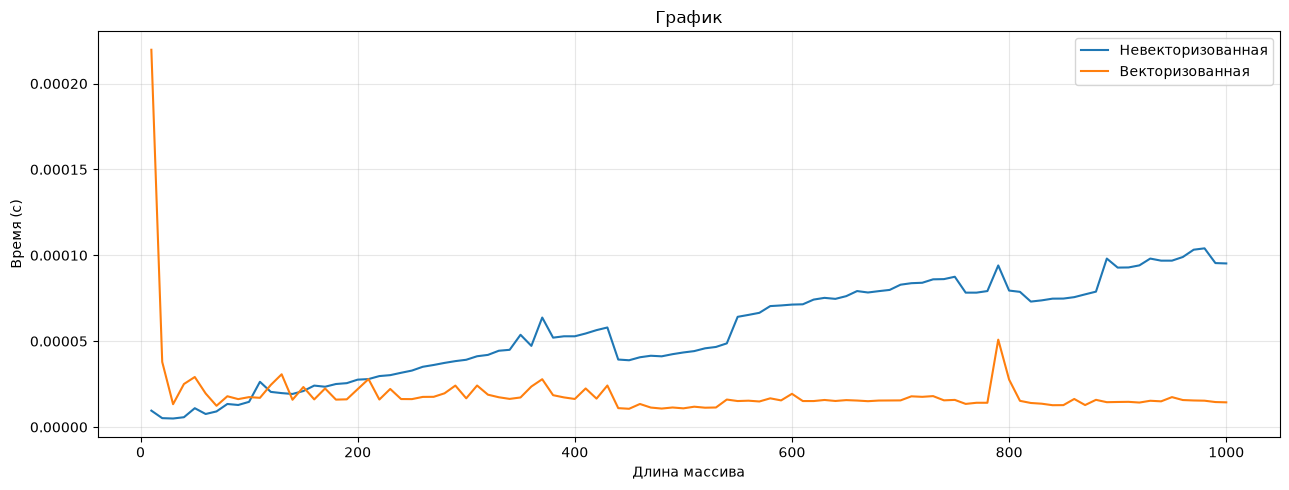

In [18]:

import time
import numpy
import matplotlib.pyplot as mat

def function1(x) :
    a = [x[0]]
    cnt = [1]
    for i in range(1, len(x)):
        if (x[i] == x[i - 1]):
            cnt[-1] += 1;
        else:
            a.append(x[i]);
            cnt.append(1);
    return (a, cnt)

def function2(x):
    a = numpy.concatenate(([True], x[1:] != x[:-1]));
    nums = x[a];
    ind = numpy.where(a)[0];
    ans = numpy.diff(numpy.append(ind, len(ind)));
    return a, ans;

size = []
time1 = []
time2 = [];

for si in range(10, 1001, 10):
    size.append(si)
    x = (numpy.random.default_rng()).integers(-100, 101, size=(si));
    y = x.tolist()
    t = time.perf_counter();
    function1(y);
    time1.append(time.perf_counter() - t);
    t = time.perf_counter();
    function2(x);
    time2.append(time.perf_counter() - t);

figure, (axis_good) = mat.subplots(1, 1, figsize=(13, 5))

axis_good.plot(size, time1, label="Невекторизованная")
axis_good.plot(size, time2, label="Векторизованная")
axis_good.set_title("График")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
mat.show()


 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

In [7]:
reload_solution_modules()

# code here


### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [8]:
# code here